<a href="https://colab.research.google.com/github/Jyotsna135-bit/GenerativeAI/blob/main/GenerativeAI/Notebooks/Deployment/Ollama/elora_chatbot_vectordb_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# eLORA RAG Chatbot v2 — Vector Database + Evaluation

This notebook builds a proper RAG pipeline for AERB's eLORA FAQ system using a vector database, hybrid search, top-k tuning, and LLM-as-judge evaluation across all 202 Q&A pairs.

**What's in here:**
- **Qdrant** vector database (in-memory, no external server needed on Colab)
- **Hybrid search** — dense (semantic) + sparse (BM25 keyword) vectors combined with RRF
- **Top-k tuning** — tests k = 1, 3, 5, 10 and picks the best
- **Full evaluation** — all 202 questions judged by the LLM itself (score 1-5)
- **Verification** — pass/fail with automatic prompt improvement for failures

> Set runtime to **T4 GPU**. Upload `eLORA-Jyotsna.xlsx` to Colab before running Step 1.

## Install and Setup

In [1]:
!apt-get install -y zstd -qq
!curl -fsSL https://ollama.com/install.sh | sh
!pip install "qdrant-client[fastembed]" pandas openpyxl tqdm openai matplotlib -q

Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import subprocess, time, requests

subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(15):
    try:
        if requests.get("http://localhost:11434").status_code == 200:
            print("ollama is running")
            break
    except:
        time.sleep(1)

!ollama pull qwen3:0.6b

ollama is running



## Step 1 — Load FAQ Data

In [3]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from openai import OpenAI

df = pd.read_excel("eLORA-Jyotsna.xlsx")

def clean_text(text):
    text = str(text)
    text = re.sub(r"&#\d+;", " ", text)
    text = text.replace("?", "'")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["faq_question"] = df["faq_question"].apply(clean_text)
df["faq_answer"]   = df["faq_answer"].apply(clean_text)

print(f"Loaded {len(df)} Q&A pairs")
df.head(3)

Loaded 202 Q&A pairs


,faq_question,faq_answer
0,"While applying for Licence, installations are ...",Please verify the login details. Licence appli...
1,I'm not able to see Telegamma Therapy equipmen...,"Ans. At present, Telegamma Therapy equipment o..."
2,"I have forgotten my password, how to obtain ne...",Visit eLORA home page and click on 'Forgot Pas...


## Step 2 — Set Up Qdrant Vector Database

Qdrant runs fully in-memory inside Colab — no server, no Docker, no cloud account. Each FAQ question is stored as two vectors:
- **Dense** (`all-MiniLM-L6-v2`) — captures semantic meaning
- **Sparse** (`Qdrant/bm25`) — captures exact keyword matches

Both are combined at query time using Reciprocal Rank Fusion (RRF).

In [4]:
from qdrant_client import QdrantClient, models

DENSE_MODEL      = "sentence-transformers/all-MiniLM-L6-v2"
SPARSE_MODEL     = "Qdrant/bm25"
COLLECTION_NAME  = "elora_faq"

client = QdrantClient(":memory:")

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config={
        "dense": models.VectorParams(
            size=client.get_embedding_size(DENSE_MODEL),
            distance=models.Distance.COSINE,
        )
    },
    sparse_vectors_config={
        "sparse": models.SparseVectorParams(
            index=models.SparseIndexParams(on_disk=False)
        )
    },
)
print(f"Collection '{COLLECTION_NAME}' created")

Collection 'elora_faq' created


## Step 3 — Upload FAQ Data to Qdrant

In [5]:
points = []
for idx, row in df.iterrows():
    points.append(
        models.PointStruct(
            id=idx,
            vector={
                "dense":  models.Document(text=row["faq_question"], model=DENSE_MODEL),
                "sparse": models.Document(text=row["faq_question"], model=SPARSE_MODEL),
            },
            payload={
                "faq_question": row["faq_question"],
                "faq_answer":   row["faq_answer"],
                "row_index":    int(idx),
            },
        )
    )

print("Uploading and embedding all FAQ entries...")
client.upsert(collection_name=COLLECTION_NAME, points=points)
print(f"Uploaded {len(points)} points to Qdrant")

Uploading and embedding all FAQ entries...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Uploaded 202 points to Qdrant


## Step 4 — Core Functions

All functions in one cell to avoid ordering issues.

In [6]:
llm_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)

VERIFICATION_K  = 3     # sir specified k=3-5
MIN_RRF_SCORE   = 0.01


# ── Retrieval ────────────────────────────────────────────────────────────────
def hybrid_search(query, top_k=VERIFICATION_K):
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            models.Prefetch(
                query=models.Document(text=query, model=SPARSE_MODEL),
                using="sparse",
                limit=top_k,
            ),
            models.Prefetch(
                query=models.Document(text=query, model=DENSE_MODEL),
                using="dense",
                limit=top_k,
            ),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k,
    )
    return response.points


# ── Generation ───────────────────────────────────────────────────────────────
def generate_answer(user_query, k=VERIFICATION_K, verbose=False):
    retrieved = hybrid_search(user_query, top_k=k)

    if not retrieved or retrieved[0].score < MIN_RRF_SCORE:
        return {
            "answer": "I'm not confident this is covered in the eLORA FAQ. Please contact AERB support.",
            "found": False,
            "matched_question": None,
            "top_score": retrieved[0].score if retrieved else 0.0,
        }

    context_blocks = [
        f"Q: {r.payload['faq_question']}\nA: {r.payload['faq_answer']}"
        for r in retrieved
    ]
    context = "\n\n".join(context_blocks)

    if verbose:
        print(f"Top match (score={retrieved[0].score:.4f}): {retrieved[0].payload['faq_question']}")

    prompt = f"""You are a helpful assistant for the eLORA system (AERB's radiation licensing portal).
Use ONLY the FAQ entries below to answer. Pick the most relevant one and answer directly.
Do not mix unrelated entries and do not add information not in the FAQ.

{context}

User's question: {user_query}

Answer:"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1500,
        temperature=0.0
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()

    return {
        "answer": raw,
        "found": True,
        "matched_question": retrieved[0].payload["faq_question"],
        "top_score": retrieved[0].score,
    }


# ── Judge ────────────────────────────────────────────────────────────────────
def judge_answer(question, ground_truth, generated):
    """Ask the LLM to compare generated vs ground truth and return a score 1-5.
    max_tokens is set high (1500) because qwen3:0.6b uses internal thinking
    tokens before its actual answer — low limits cause empty responses."""
    judge_prompt = f"""You are evaluating a chatbot answer against the correct reference answer.

Question: {question}
Reference answer: {ground_truth}
Chatbot answer: {generated}

Score 1-5:
5 = fully correct, same information as reference
4 = mostly correct, minor details missing
3 = partially correct, some key info missing
2 = mostly incorrect but topic related
1 = completely wrong

Respond EXACTLY in this format:
SCORE: <number>
REASON: <one sentence>"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": judge_prompt}],
        max_tokens=1500,
        temperature=0.0
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return raw


def parse_judge_output(text):
    score_match  = re.search(r"SCORE:\s*(\d)", text)
    reason_match = re.search(r"REASON:\s*(.+)", text)
    if score_match:
        score = int(score_match.group(1))
    else:
        fallback = re.search(r"\b([1-5])\b", text)
        score = int(fallback.group(1)) if fallback else None
    reason = reason_match.group(1).strip() if reason_match else text[:150]
    return score, reason


# quick sanity check
results = hybrid_search("I forgot my password", top_k=3)
for r in results:
    print(f"score={r.score:.4f} | {r.payload['faq_question']}")

score=0.7500 | I have forgotten my password, how to obtain new password'
score=0.7500 | I have forgotten my password, how to obtain new password
score=0.6667 | I have forgotten my password, how to obtain new password'


## Step 5 — Find the Best k

Testing k = 1, 3, 5, 10 using recall@k — how often the correct FAQ entry appears in the top-k results.

In [7]:
def evaluate_recall_at_k(k_values):
    results = {}
    for k in k_values:
        correct = 0
        for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"k={k}"):
            retrieved = hybrid_search(row["faq_question"], top_k=k)
            retrieved_ids = [r.payload["row_index"] for r in retrieved]
            if idx in retrieved_ids:
                correct += 1
        recall = correct / len(df)
        results[k] = recall
        print(f"k={k}: recall@{k} = {recall:.4f} ({correct}/{len(df)})")
    return results

recall_results = evaluate_recall_at_k([1, 3, 5, 10])


k=1: 100%|██████████| 202/202 [00:12<00:00, 15.94it/s]


k=1: recall@1 = 0.8762 (177/202)



k=3: 100%|██████████| 202/202 [00:12<00:00, 16.48it/s]


k=3: recall@3 = 0.9802 (198/202)



k=5: 100%|██████████| 202/202 [00:11<00:00, 16.98it/s]


k=5: recall@5 = 1.0000 (202/202)



k=10: 100%|██████████| 202/202 [00:11<00:00, 17.52it/s]

k=10: recall@10 = 1.0000 (202/202)


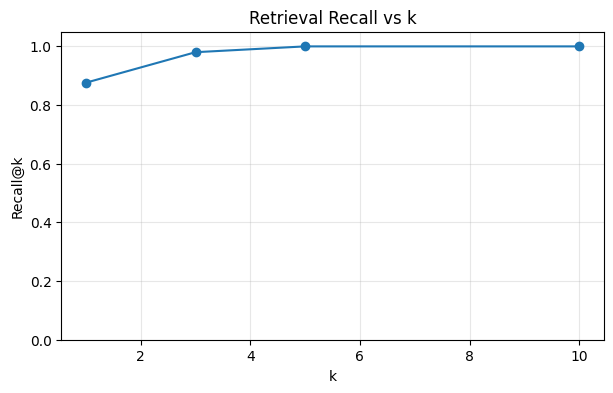

Chosen k = 5 (recall = 1.0000)


In [8]:
ks      = list(recall_results.keys())
recalls = list(recall_results.values())

plt.figure(figsize=(7, 4))
plt.plot(ks, recalls, marker="o")
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Retrieval Recall vs k")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

best_recall = max(recalls)
BEST_K = min(k for k, r in recall_results.items() if r >= best_recall - 0.01)
print(f"Chosen k = {BEST_K} (recall = {recall_results[BEST_K]:.4f})")

## Step 6 — Quick Generation Test

In [9]:
result = generate_answer("How do I check my application status?", verbose=True)
print("\nAnswer:", result["answer"])

Top match (score=1.0000): I have submitted application form for Institute registration, how to check its status'

Answer: To check your application status, please use the "Application Status" option provided on the eLORA home page. This will help you track the status of your application.


## Step 7 — Evaluate All 202 Q&A Pairs (LLM-as-Judge)

Running every FAQ question through the full pipeline and scoring each answer 1-5 against the ground truth.

**Note:** `qwen3:0.6b` uses internal thinking before answering, so each call allows up to 1500 tokens. This step takes 15-20 minutes on T4.

In [10]:
eval_records = []

print(f"Evaluating all {len(df)} Q&A pairs...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    question     = row["faq_question"]
    ground_truth = row["faq_answer"]

    result    = generate_answer(question, k=BEST_K)
    generated = result["answer"]

    judge_raw        = judge_answer(question, ground_truth, generated)
    score, reason    = parse_judge_output(judge_raw)

    eval_records.append({
        "row_index":         idx,
        "question":          question,
        "ground_truth":      ground_truth,
        "generated_answer":  generated,
        "found":             result["found"],
        "matched_question":  result["matched_question"],
        "retrieval_correct": result["matched_question"] == question,
        "judge_score":       score,
        "judge_reason":      reason,
    })

eval_df = pd.DataFrame(eval_records)
print(f"\nDone. Scores populated: {eval_df['judge_score'].notna().sum()} / {len(eval_df)}")
eval_df.head()

Evaluating all 202 Q&A pairs...



100%|██████████| 202/202 [11:35<00:00,  3.44s/it]


Done. Scores populated: 202 / 202


,row_index,question,ground_truth,generated_answer,found,matched_question,retrieval_correct,judge_score,judge_reason
0,0,"While applying for Licence, installations are ...",Please verify the login details. Licence appli...,Please verify the login details. Licence appli...,True,"While applying for Licence, installations are ...",True,5,The information provided matches the reference...
1,1,I'm not able to see Telegamma Therapy equipmen...,"Ans. At present, Telegamma Therapy equipment o...",A: Please check the status of the associated r...,True,I'm not able to see Telegamma Therapy equipmen...,True,5,The reference answer correctly identifies the ...
2,2,"I have forgotten my password, how to obtain ne...",Visit eLORA home page and click on 'Forgot Pas...,"Visit eLORA home page and click on ""Forgot Pas...",True,"I have forgotten my password, how to obtain ne...",True,5,Both answers correctly provide the same inform...
3,3,How to change email address of Institute Emplo...,"After login, follow the Menu 'User Management-...","After login, follow the menu ""User Management ...",True,How to change email address of Institute Emplo...,True,5,Both answers correctly follow the reference's ...
4,4,We have submitted application form through my ...,The status of all application form can be seen...,"After login, follow the Menu: 'My Applications...",True,We have submitted application form through my ...,True,5,The information provided exactly matches the r...


## Step 8 — Results Summary

In [11]:
valid_scores = eval_df["judge_score"].dropna()

print("=" * 60)
print("OVERALL RESULTS")
print("=" * 60)
print(f"Total questions evaluated:        {len(eval_df)}")
print(f"Scores successfully parsed:       {valid_scores.count()}")
print(f"Retrieval found correct FAQ:      {eval_df['retrieval_correct'].sum()} / {len(eval_df)} ({eval_df['retrieval_correct'].mean()*100:.1f}%)")
print(f"Average judge score (1-5):        {valid_scores.mean():.2f}")
print(f"Answers scored 4-5 (good):        {(valid_scores >= 4).sum()} ({(valid_scores >= 4).mean()*100:.1f}%)")
print(f"Answers scored 1-2 (poor):        {(valid_scores <= 2).sum()} ({(valid_scores <= 2).mean()*100:.1f}%)")
print()
print("Score distribution:")
print(eval_df["judge_score"].value_counts().sort_index(ascending=False))

OVERALL RESULTS
Total questions evaluated:        202
Scores successfully parsed:       202
Retrieval found correct FAQ:      195 / 202 (96.5%)
Average judge score (1-5):        4.62
Answers scored 4-5 (good):        181 (89.6%)
Answers scored 1-2 (poor):        3 (1.5%)

Score distribution:
judge_score
5    150
4     31
3     18
2      2
1      1
Name: count, dtype: int64


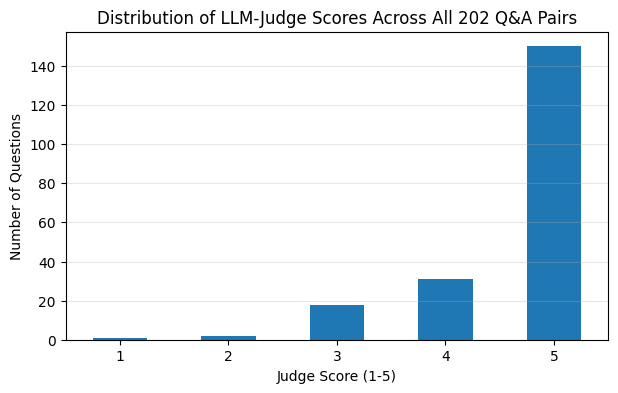

In [12]:
score_counts = eval_df["judge_score"].value_counts().sort_index()

if len(score_counts) > 0:
    plt.figure(figsize=(7, 4))
    score_counts.plot(kind="bar")
    plt.xlabel("Judge Score (1-5)")
    plt.ylabel("Number of Questions")
    plt.title("Distribution of LLM-Judge Scores Across All 202 Q&A Pairs")
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3, axis="y")
    plt.show()
else:
    print("No scores to plot — re-run Step 7 to populate eval_df.")

## Step 9 — Look at the Failures

In [13]:
worst_cases = eval_df[eval_df["judge_score"] <= 2].sort_values("judge_score")
print(f"{len(worst_cases)} low-scoring cases out of {len(eval_df)}\n")

for _, row in worst_cases.head(10).iterrows():
    print("-" * 65)
    print(f"Question:     {row['question']}")
    print(f"Correct FAQ:  {row['retrieval_correct']}")
    print(f"Ground truth: {row['ground_truth'][:150]}")
    print(f"Generated:    {row['generated_answer'][:150]}")
    print(f"Score: {row['judge_score']} — {row['judge_reason']}")
    print()

3 low-scoring cases out of 202

-----------------------------------------------------------------
Question:     As per the current norms employer acts as the licensee as well. How do I change the Licesee in eLORA '
Correct FAQ:  True
Ground truth: For changing the employer/licensee one has to use the 'Change of Employer' application available in eLORA. Please note incoming Employer will become t
Generated:    For changing the Licensee in eLORA, follow the "Change of Employer" application process. When the current employer acts as the licensee, the outgoing 
Score: 1 — The reference answer correctly identifies the process for changing the employer, while the chatbot answer incorrectly refers to the Licensee instead of the Employer.

-----------------------------------------------------------------
Question:     How to update institute profile'
Correct FAQ:  True
Ground truth: Login through Employer's account, use following path Menu: 'User Management' --> update institute details--> cli

## Step 10 — Verification (Pass / Fail / Improved Prompt)

As sir specified: for each question, check if the answer is correct. If not, try an improved prompt. If that still fails, flag it as needing a better LLM.

In [14]:
def improved_prompt_answer(user_query, retrieved):
    context_blocks = [
        f"Q: {r.payload['faq_question']}\nA: {r.payload['faq_answer']}"
        for r in retrieved
    ]
    context = "\n\n".join(context_blocks)

    prompt = f"""You are answering questions about the eLORA radiation licensing system.
Below are the most relevant FAQ entries. Give a short, direct answer.
Do NOT say 'based on the FAQ' — just answer directly.

{context}

Question: {user_query}
Answer:"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1500,
        temperature=0.0
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return raw


verif_records = []
print(f"Verifying all {len(df)} Q&A pairs with k={VERIFICATION_K}...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    question     = row["faq_question"]
    ground_truth = row["faq_answer"]

    retrieved = hybrid_search(question, top_k=VERIFICATION_K)
    result    = generate_answer(question, k=VERIFICATION_K)
    generated = result["answer"]

    raw1             = judge_answer(question, ground_truth, generated)
    score1, reason1  = parse_judge_output(raw1)

    improved_answer  = None
    score2, reason2  = None, None
    final_status     = "PASS" if (score1 or 0) >= 3 else "FAIL"

    if final_status == "FAIL" and retrieved:
        improved_answer = improved_prompt_answer(question, retrieved)
        raw2            = judge_answer(question, ground_truth, improved_answer)
        score2, reason2 = parse_judge_output(raw2)
        if (score2 or 0) >= 3:
            final_status = "PASS (improved prompt)"
        else:
            final_status = "FAIL — needs better LLM"

    verif_records.append({
        "row_index":        idx,
        "question":         question,
        "ground_truth":     ground_truth,
        "generated_answer": generated,
        "first_score":      score1,
        "first_reason":     reason1,
        "improved_answer":  improved_answer,
        "improved_score":   score2,
        "improved_reason":  reason2,
        "final_status":     final_status,
    })

verif_df = pd.DataFrame(verif_records)
print("\nVerification complete.")

Verifying all 202 Q&A pairs with k=3...



100%|██████████| 202/202 [11:37<00:00,  3.45s/it]


Verification complete.


In [15]:
total  = len(verif_df)
passed = verif_df["final_status"].str.startswith("PASS").sum()
fixed  = (verif_df["final_status"] == "PASS (improved prompt)").sum()
failed = (verif_df["final_status"] == "FAIL — needs better LLM").sum()

print("=" * 60)
print("VERIFICATION RESULTS")
print("=" * 60)
print(f"Total questions:               {total}")
print(f"PASS (first attempt):          {passed - fixed}  ({(passed-fixed)/total*100:.1f}%)")
print(f"PASS (fixed by better prompt): {fixed}  ({fixed/total*100:.1f}%)")
print(f"FAIL (needs better LLM):       {failed}  ({failed/total*100:.1f}%)")
print()

if failed > 0:
    print("Cases that need a better LLM:")
    needs_better = verif_df[verif_df["final_status"] == "FAIL — needs better LLM"]
    for _, row in needs_better.head(10).iterrows():
        print("-" * 60)
        print(f"Q: {row['question']}")
        print(f"Ground truth:  {row['ground_truth'][:120]}")
        print(f"Generated:     {row['generated_answer'][:120]}")
        print(f"Scores: {row['first_score']} -> {row['improved_score']}")
        print()

VERIFICATION RESULTS
Total questions:               202
PASS (first attempt):          201  (99.5%)
PASS (fixed by better prompt): 1  (0.5%)
FAIL (needs better LLM):       0  (0.0%)



## Step 11 — Save Results

In [16]:
eval_df.to_csv("elora_rag_evaluation_results.csv", index=False)
verif_df.to_csv("elora_verification_results.csv", index=False)

print("Saved:")
print("  elora_rag_evaluation_results.csv  — full eval with judge scores")
print("  elora_verification_results.csv    — pass/fail verification")
print("\nDownload from the Files panel on the left sidebar.")

Saved:
  elora_rag_evaluation_results.csv  — full eval with judge scores
  elora_verification_results.csv    — pass/fail verification

Download from the Files panel on the left sidebar.


## Summary

| | |
|---|---|
| Vector database | Qdrant, in-memory |
| Dense model | `sentence-transformers/all-MiniLM-L6-v2` |
| Sparse model | `Qdrant/bm25` |
| Fusion | Reciprocal Rank Fusion (RRF) |
| k used | 3 (tuned in Step 5) |
| LLM | `qwen3:0.6b` via Ollama |
| Evaluation | LLM-as-judge, score 1-5, all 202 pairs |
| Verification | pass/fail with automatic improved prompt fallback |